In [1]:
import pandas as pd
import numpy as np
import os
import random
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load supervised_df
df_full = pd.read_csv('bco_supervised_clean.csv')
# df_balanced = pd.read_csv('bco_balanced_clean.csv')

In [3]:
print(f"df_full year value counts:\n{df_full['year'].value_counts()/len(df_full['year'])*100})")

print(f"df_balanced year value counts:\n{df_balanced['year'].value_counts()/len(df_balanced['year'])*100}")

df_full year value counts:
year
2005    11.497621
2006     8.079958
2009     5.674829
2008     5.564582
2016     5.254149
2004     4.940815
2003     4.827666
2010     4.734827
2017     4.592666
2007     4.528838
2015     4.523036
2013     4.418591
2014     4.087850
2012     4.064640
2011     3.936985
2018     3.606243
2019     3.446675
2002     2.860624
1998     2.590809
1999     2.167228
2001     2.126610
2000     1.795869
2020     0.261112
1996     0.078334
1997     0.063827
1994     0.055124
1987     0.049321
1983     0.043519
1993     0.026111
1992     0.023210
1991     0.020309
1988     0.017407
1995     0.017407
1986     0.008704
1990     0.008704
1980     0.005802
Name: count, dtype: float64)
df_balanced year value counts:
year
2005    20.046936
2006     8.827512
2016     6.805668
1998     6.065529
2009     4.892138
2010     4.621356
2015     4.558173
2014     3.790956
2007     3.781930
2008     3.727773
2002     3.556278
2011     3.420886
2013     3.249391
2004     3.231339
201

For splitting the data I can create temporal splits like - for df_full 1980-2009 - 57.07% for train set; 2010-2014 - 21.24% for val set and 2015-2020 - 21.68% for test set. <br>
- 1980–2009 (train): Captures pre-mass-bleaching-era baseline + the catastrophic 1998 El Niño event ( biggest bleaching signal) - model learns historical patterns
- 2010–2014 (val): Post-2010 recovery/monitoring period - tuning happens on a distinct climate window
- 2015–2020 (test): Includes 2016 Great Barrier Reef mass bleaching - the most severe on record. This is the hardest and most realistic test set.

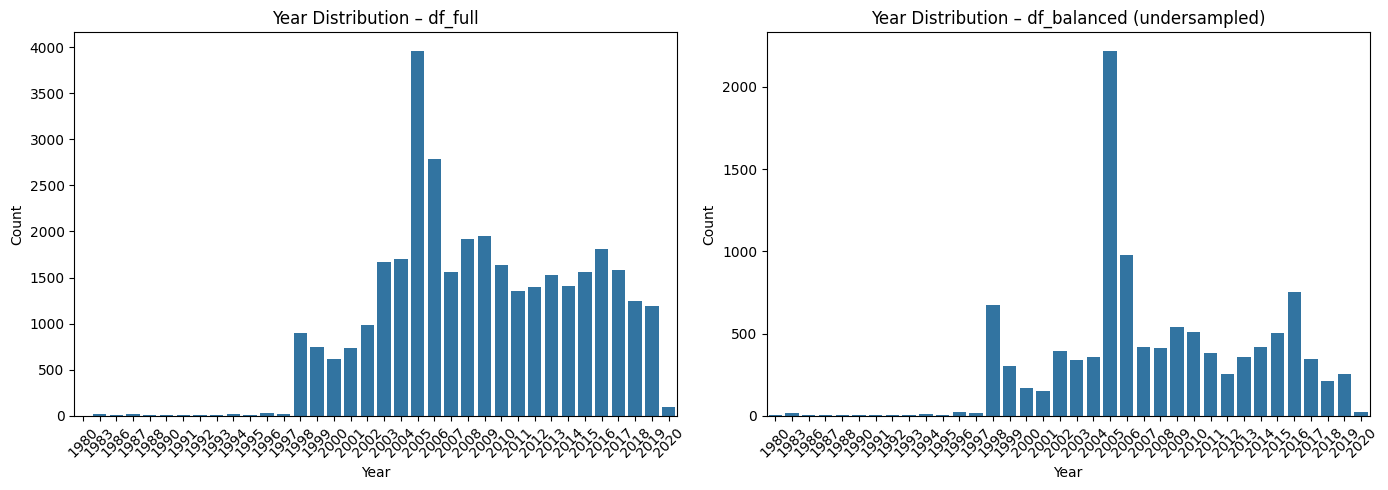

In [4]:
# Plot years distribution for splitting data
plt.figure(figsize=(14, 5))

# --- df_full ---
plt.subplot(1, 2, 1)
sns.countplot(data=df_full, x='year', order=sorted(df_full['year'].unique()))
plt.title('Year Distribution – df_full')
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.ylabel('Count')

# --- df_balanced ---
plt.subplot(1, 2, 2)
sns.countplot(data=df_balanced, x='year', order=sorted(df_balanced['year'].unique()))
plt.title('Year Distribution – df_balanced (undersampled)')
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


In [5]:
df_full.groupby(['year', 'bleaching_bin']).size().unstack(fill_value=0)

bleaching_bin,high,low,medium
year,,,
1980,2,0,0
1983,15,0,0
1986,3,0,0
1987,5,12,0
1988,6,0,0
1990,2,1,0
1991,5,2,0
1992,3,5,0
1993,4,5,0


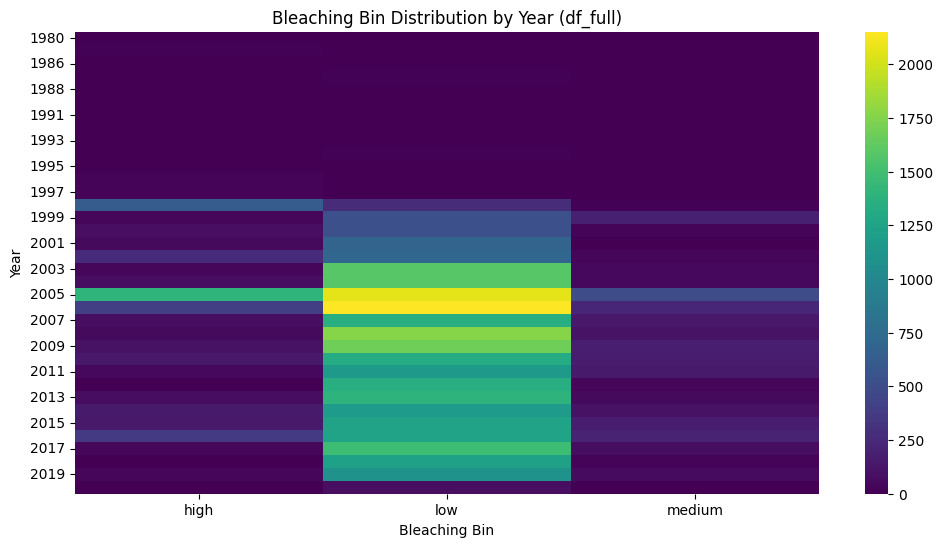

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

ct = df_full.groupby(['year', 'bleaching_bin']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(ct, cmap='viridis', annot=False)
plt.title('Bleaching Bin Distribution by Year (df_full)')
plt.ylabel('Year')
plt.xlabel('Bleaching Bin')
plt.show()

In [7]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# contingency table
ct = pd.crosstab(df_full['year'], df_full['bleaching_bin'])

# chi-square
chi2, p, dof, expected = chi2_contingency(ct)

# Cramer's V
n = ct.sum().sum()
phi2 = chi2 / n
r, k = ct.shape
cramers_v = np.sqrt(phi2 / min(k-1, r-1))

cramers_v


np.float64(0.34235069550709396)

In [8]:
# Identify feature columns, exclude target
feature_cols = [col for col in df_full.columns if col != 'bleaching_bin']
X_full = df_full[feature_cols]
y_full = df_full['bleaching_bin']

X_balanced = df_balanced[feature_cols]
y_balanced = df_balanced['bleaching_bin']

In [9]:
# Temporal split based on years
train_years = [1980, 2009]  # inclusive range
val_years = [2010, 2014]
test_years = [2015, 2020]

# For df_full
X_train_full = X_full[df_full['year'].between(train_years[0], train_years[1])]
y_train_full = y_full[df_full['year'].between(train_years[0], train_years[1])]

X_val_full = X_full[df_full['year'].between(val_years[0], val_years[1])]
y_val_full = y_full[df_full['year'].between(val_years[0], val_years[1])]

X_test_full = X_full[df_full['year'].between(test_years[0], test_years[1])]
y_test_full = y_full[df_full['year'].between(test_years[0], test_years[1])]

# For df_balanced
X_train_bal = X_balanced[df_balanced['year'].between(train_years[0], train_years[1])]
y_train_bal = y_balanced[df_balanced['year'].between(train_years[0], train_years[1])]

X_val_bal = X_balanced[df_balanced['year'].between(val_years[0], val_years[1])]
y_val_bal = y_balanced[df_balanced['year'].between(val_years[0], val_years[1])]

X_test_bal = X_balanced[df_balanced['year'].between(test_years[0], test_years[1])]
y_test_bal = y_balanced[df_balanced['year'].between(test_years[0], test_years[1])]

print(f"Shape of X_train_full: {X_train_full.shape}")
print(f"Shape of y_train_full: {y_train_full.shape}")
print(f"Shape of X_val_full: {X_val_full.shape}")
print(f"Shape of y_val_full: {y_val_full.shape}")
print(f"Shape of X_test_full: {X_test_full.shape}")
print(f"Shape of y_test_full: {y_test_full.shape}")

print(f"\nShape of X_train_balanced: {X_train_bal.shape}")
print(f"Shape of y_train_balanced: {y_train_bal.shape}")
print(f"Shape of X_val_balanced: {X_val_bal.shape}")
print(f"Shape of y_val_balanced: {y_val_bal.shape}")
print(f"Shape of X_test_balanced: {X_test_bal.shape}")
print(f"Shape of y_test_balanced: {y_test_bal.shape}")

Shape of X_train_full: (19672, 36)
Shape of y_train_full: (19672,)
Shape of X_val_full: (7322, 36)
Shape of y_val_full: (7322,)
Shape of X_test_full: (7474, 36)
Shape of y_test_full: (7474,)

Shape of X_train_balanced: (7067, 36)
Shape of y_train_balanced: (7067,)
Shape of X_val_balanced: (1926, 36)
Shape of y_val_balanced: (1926,)
Shape of X_test_balanced: (2086, 36)
Shape of y_test_balanced: (2086,)


In [ ]:
# Undersample the majority class
from sklearn.utils import resample

# Separate classes
df_low = df_supervised[df_supervised['bleaching_bin'] == 'low']
df_medium = df_supervised[df_supervised['bleaching_bin'] == 'medium']
df_high = df_supervised[df_supervised['bleaching_bin'] == 'high']


# target size can be min, max or avg len of other 2 categories.
target_size = max(len(df_medium), len(df_high)) # 4288 samples

# Undersample low class
df_low_undersampled = resample(
    df_low,
    replace=False,
    n_samples=target_size,
    random_state=42
)

# Combine balanced dataset
df_balanced = pd.concat([df_low_undersampled, df_medium, df_high])

print(f"Original size: {len(df_supervised)}")
print(f"Balanced size: {len(df_balanced)}")
print(f"New distribution:\n{df_balanced['bleaching_bin'].value_counts()}")

#### Df full, reduced data, experiments

In [4]:
df_full['substrate_name'] = df_full['substrate_name'].fillna('unknown')
bins = [-0.01, 1, 30, 100]

labels = [0, 1, 2]  # 0=low, 1=medium, 2=high

df_full['bleaching_class'] = pd.cut(
    df_full['percent_bleaching'],
    bins=bins,
    labels=labels,
    include_lowest=True
).astype(int)

# Drop columns not used in modelling
df_full = df_full.drop(columns=['percent_bleaching', 'date', 'percent_cover'], errors='ignore')

## Identify feature columns
feature_cols = [col for col in df_full.columns if col != 'bleaching_class']

# Define X and y variables
X = df_full[feature_cols]
y = df_full['bleaching_class']


In [6]:
import pandas as pd
import numpy as np
import os
import random
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import metrics

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                                 ConfusionMatrixDisplay, precision_recall_fscore_support)

2026-04-08 11:48:40.896117: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-08 11:48:40.904475: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 11:48:41.259971: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-08 11:48:42.667062: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

 # Shape of each dataframe
print('Size of X_train', X_train.shape)
print('Size of Y_train', y_train.shape)
print('Size of X_val', X_val.shape)
print('Size of Y_val', y_val.shape)
print('Size of X_test', X_test.shape)
print('Size of Y_test', y_test.shape)

Size of X_train (20680, 35)
Size of Y_train (20680,)
Size of X_val (6894, 35)
Size of Y_val (6894,)
Size of X_test (6894, 35)
Size of Y_test (6894,)


In [8]:
# df for y_train and X_train
df_train = pd.concat([pd.DataFrame(y_train), pd.DataFrame(X_train)], axis=1)

In [9]:
# group feature columns for analysis
feature_groups = {
'Spatial': ['latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'depth_m'], #4
'thermal_baseline': ['climsst', 'ssta', 'tsa', 'ssta_dhw', 'tsa_dhw'], #5
'ssta_family': [ 'ssta_standard_deviation', 'ssta_maximum', 'ssta_frequency', #9
       'ssta_frequency_standard_deviation', 'ssta_frequencymax',
       'ssta_frequencymean', 'ssta_dhw_standard_deviation', 'ssta_dhwmax', 
       'ssta_dhwmean'],
'tsa_family': ['tsa_standard_deviation', 'tsa_maximum', 'tsa_frequency', #9
       'tsa_frequency_standard_deviation', 'tsa_frequencymax', 'tsa_frequencymean', 
       'tsa_dhw_standard_deviation', 'tsa_dhwmax', 'tsa_dhwmean'],
'environmental': ['temperature_mean', 'temperature_maximum', 'windspeed', 'turbidity', #5
                  'cyclone_frequency'],
# 'categorical': ['exposure', 'substrate_name'], #2
'temporal': ['year'], #1
}

In [10]:
# Numeric columns for correlation matrix
numeric_cols = numeric_cols = df_train[feature_cols].select_dtypes(include=['int64', 'float64']).columns

In [11]:
keep_features = {
'Spatial': ['latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'depth_m'],
'thermal_baseline': ['climsst', 'ssta', 'tsa', 'ssta_dhw'],
'ssta_family': ['ssta_standard_deviation','ssta_frequency'],
'tsa_family': ['tsa_frequency'],
'environmental': ['turbidity', 'cyclone_frequency'],
'temporal': ['year'],
'categorical': ['exposure', 'substrate_name']}

In [12]:
# Flatten the keep_features dictionary into a single list
keep_features_flat = [f for group in keep_features.values() for f in group]

# copy to a new dataframe
df_train = df_train[keep_features_flat]

In [13]:
# Features for baseline model
numeric_features = [
    'latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'depth_m', 'ssta', 
    'tsa', 'ssta_dhw', 'ssta_frequency', 'tsa_frequency', 'turbidity', 'year']

categorical_features = ['exposure', 'substrate_name']

In [ ]:
def train_logistic_model(df):
    """
    Build, preprocess, and train a Logistic Regression baseline classifier for coral bleaching
     severity prediction.
     Constructs a sklearn Pipeline to handle preprocessing.
     Model:
    ------
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced', 
        C=1.0 )

    Multi-class strategy defaults to 'auto', which uses One-vs-Rest (OvR) for
    this problem. Each class is treated as a binary problem against all others.

    Parameters
    ----------
    df : pd.DataFrame
        Training dataframe

    Returns
    -------
    model : sklearn.pipeline.Pipeline
        Fitted pipeline (preprocessor + classifier).
    X_train, X_val, X_test : pd.DataFrame
        Feature splits (passed through for use in evaluation).
    y_train, y_val, y_test : pd.Series
        Target splits.
    """
    # Preprocessing
    # -------------------------
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    # Model
    # -------------------------
    model = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0))
    ])

    # Train
    model.fit(X_train, y_train)

    return model, X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
def evaluate_model(model, X_val, y_val):

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Overall Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    acc_gap = abs(train_acc - val_acc)

    # Per-class metrics
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_val_pred)
    
    cm = confusion_matrix(y_val, y_val_pred)
    cm_train = confusion_matrix(y_train, y_train_pred)
    
    # Per-class accuracies
    train_class_acc = [cm_train[i,i]/cm_train[i].sum() if cm_train[i].sum() > 0 else 0 for i in range(3)]
    val_class_acc = [cm[i,i]/cm[i].sum() if cm[i].sum() > 0 else 0 for i in range(3)]
    
    # Create results DataFrame
    results_data = []
    for i in range(3):
        results_data.append({
            'Class': ['Low Bleaching', 'Medium Bleaching', 'High Bleaching'][i],
            'Train Acc': f"{train_class_acc[i]:.3f}",
            'Val Acc': f"{val_class_acc[i]:.3f}",
            'Acc Gap': f"{train_class_acc[i] - val_class_acc[i]:.3f}",
            'Precision': f"{precision[i]:.3f}",
            'Recall': f"{recall[i]:.3f}",
            'F1': f"{f1[i]:.3f}"
        })
    
    # Add overall row
    results_data.append({
        'Class': 'Overall',
        'Train Acc': f"{train_acc:.3f}",
        'Val Acc': f"{val_acc:.3f}",
        'Acc Gap': f"{acc_gap:.3f}",
        'Precision': '-',
        'Recall': '-',
        'F1': '-'
    })
    
    results_df = pd.DataFrame(results_data)
    print(results_df.to_string(index=False))

    # print("Classification Report (Validation Set):")
    # print(classification_report(y_val, y_val_pred, 
    #                             target_names=['Low Bleaching', 'Medium Bleaching', 'High Bleaching']))

    # Plot confusion matrix
    ConfusionMatrixDisplay(cm, display_labels=['Low Bleaching: 0', 'Medium Bleaching: 1', 
                                               'High Bleaching: 3']).plot(cmap='Blues')
    plt.xticks(rotation=30)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    FP = cm.sum(axis=0) - np.diag(cm)
    FN = cm.sum(axis=1) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)

    for i in range(len(TP)):
        print(f"\nClass {i}:")
        print(f"  TP = {TP[i]}")
        print(f"  FP = {FP[i]}")
        print(f"  FN = {FN[i]}")
        print(f"  TN = {TN[i]}")    
    
    return cm, metrics